In [37]:
#Imports
# Basic data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Make plots look clean
sns.set_style("whitegrid")

In [19]:
#Load Dataset
df = pd.read_csv("../data/vanet_traffic_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (195714, 27)


,timestamp,road_segment_id,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,...,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label
0,2025-09-29T04:54:49,S090,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,...,51.66,-60.28,5.56,1.7504,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate
1,2025-09-30T06:15:38,S339,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,...,204.45,-69.48,30.34,0.0502,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock
2,2025-09-29T05:46:06,S167,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,...,49.53,-58.90,4.60,1.5510,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate
3,2025-09-28T21:15:29,S030,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,...,49.64,-60.43,5.30,1.4700,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate
4,2025-09-28T00:29:20,S261,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,...,21.00,-55.23,0.30,12.6102,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow


In [20]:
#Information regarding dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195714 entries, 0 to 195713
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   timestamp                      195714 non-null  str    
 1   road_segment_id                195714 non-null  str    
 2   avg_speed_kmph                 195714 non-null  float64
 3   density_veh_per_km             195714 non-null  float64
 4   avg_wait_time_s                195714 non-null  float64
 5   occupancy_pct                  195714 non-null  float64
 6   flow_veh_per_hr                195714 non-null  float64
 7   queue_length_veh               195714 non-null  float64
 8   avg_accel_ms2                  195714 non-null  float64
 9   heading_deg                    195714 non-null  float64
 10  signal_state_num               195714 non-null  float64
 11  incident_num                   195714 non-null  float64
 12  temp_c                         195714 non

In [21]:
#Dataset Audit + Required Plots => EDA
print("Rows, Columns:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum(), "total missing values")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget class distribution:\n", df["label"].value_counts())
print("\nTarget class distribution (%):\n", df["label"].value_counts(normalize=True) * 100)

Rows, Columns: (195714, 27)

Data types:
 timestamp                            str
road_segment_id                      str
avg_speed_kmph                   float64
density_veh_per_km               float64
avg_wait_time_s                  float64
occupancy_pct                    float64
flow_veh_per_hr                  float64
queue_length_veh                 float64
avg_accel_ms2                    float64
heading_deg                      float64
signal_state_num                 float64
incident_num                     float64
temp_c                           float64
visibility_km                    float64
rain_intensity_mmph              float64
channel_busy_ratio_pct           float64
msg_rate_hz                      float64
avg_comm_delay_ms                float64
rssi_dbm                         float64
packet_loss_pct                  float64
speed_density_ratio              float64
congestion_pressure              float64
wireless_congestion_intensity    float64
throughput_per_

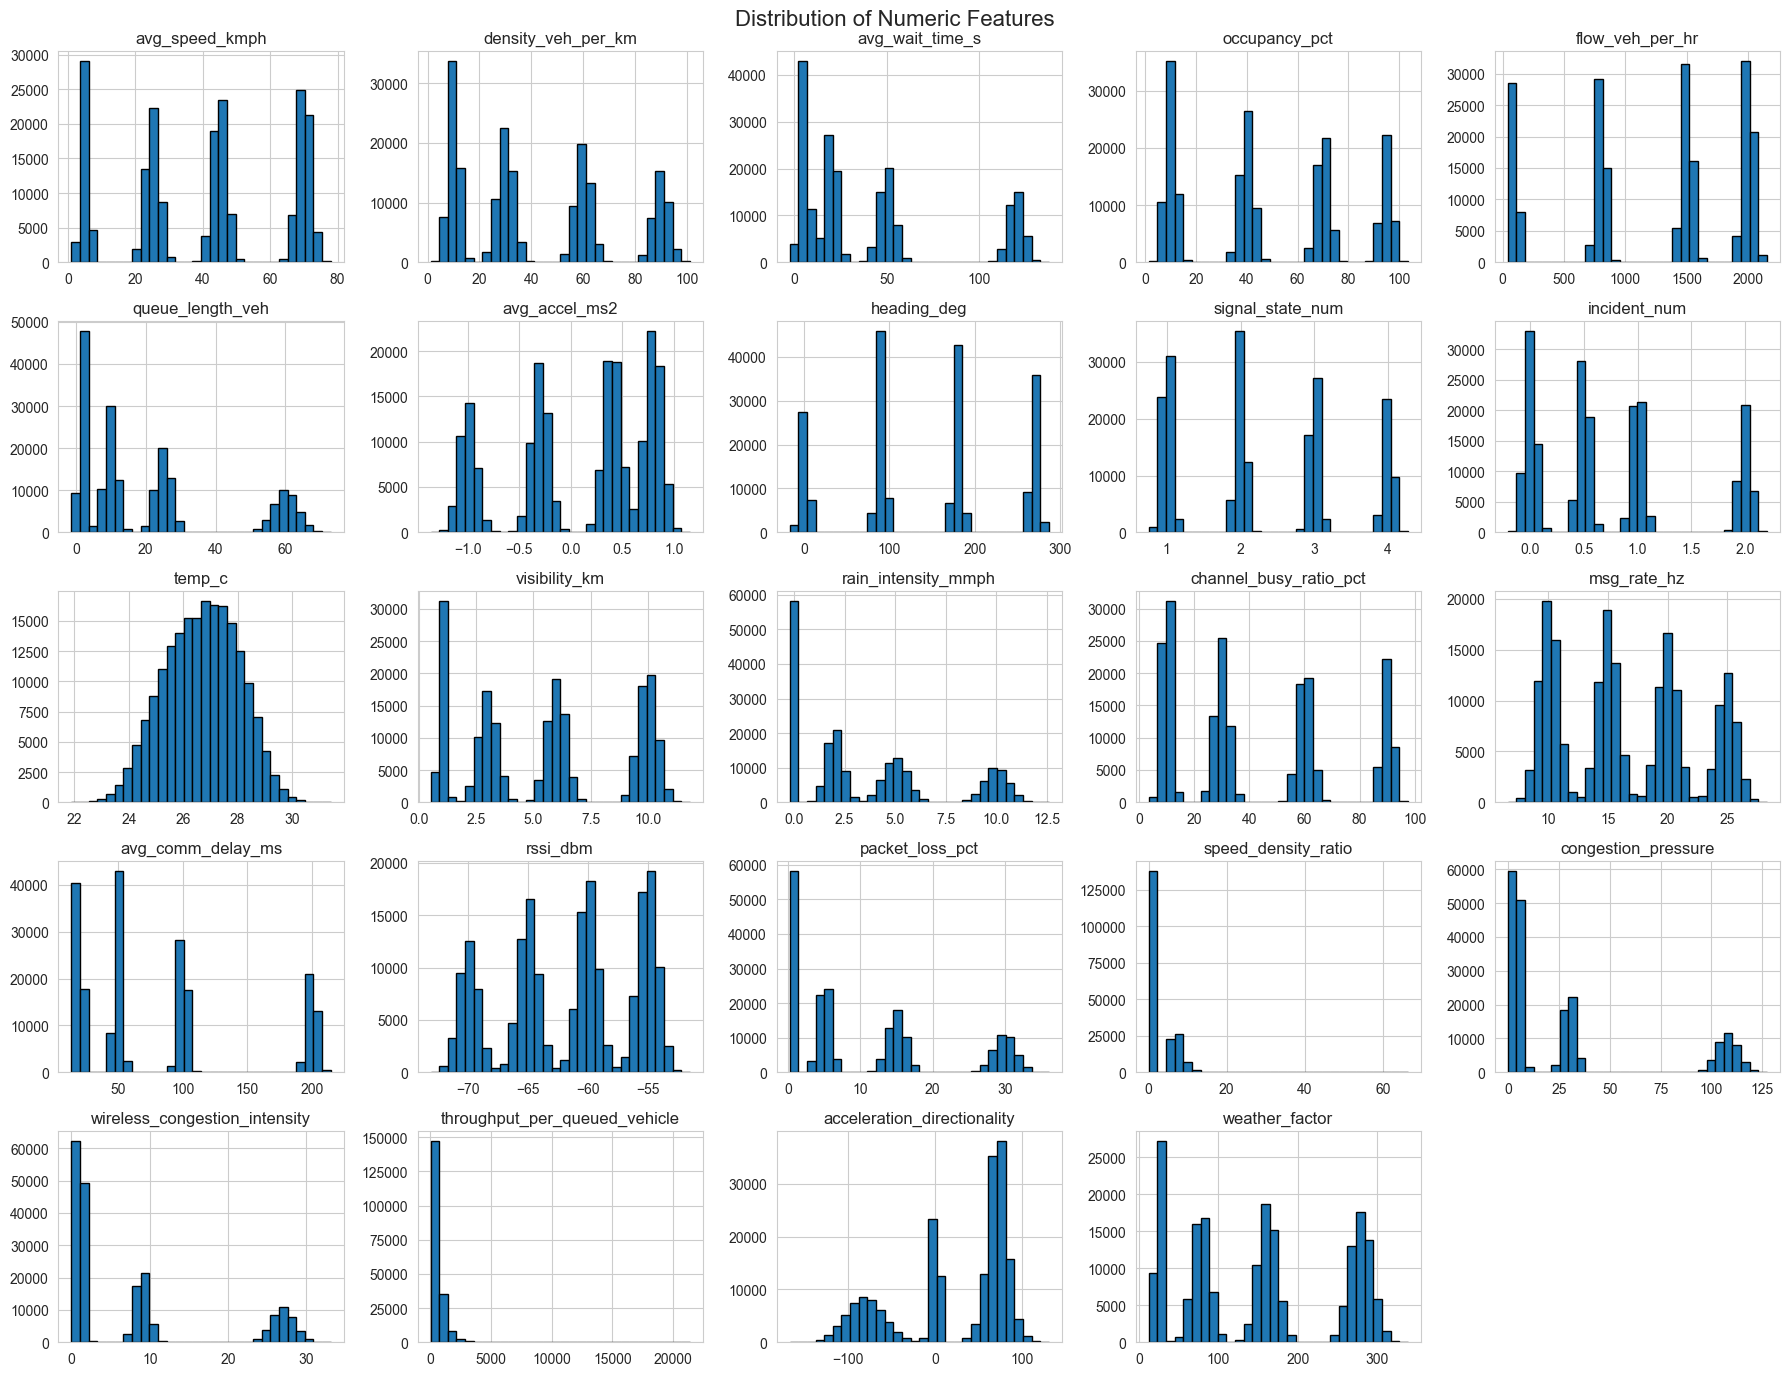

In [22]:
##Distribution Plots for Each Feature
numeric_features = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

df[numeric_features].hist(figsize=(18, 14), bins=30, edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

Insight:Most core traffic features (avg_speed_kmph, density_veh_per_km, occupancy_pct) show multi-modal shapes — this matches the four traffic conditions producing different typical value ranges. A few features like throughput_per_queued_vehicle show a long right tail, indicating outliers.

C:\Users\manin\AppData\Local\Temp\ipykernel_27292\2618213280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="label", order=df["label"].value_counts().index, palette="tab10")


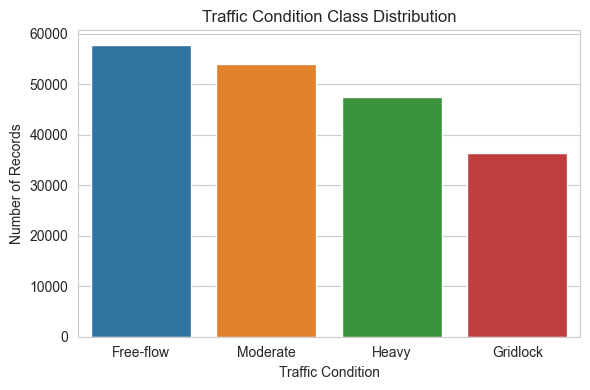

In [23]:
#Target Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index, palette="tab10")
plt.title("Traffic Condition Class Distribution")
plt.xlabel("Traffic Condition")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

Insight:The four groups are roughly the same size (18% to 30% each). Because they are already well-balanced, you do not need to use special tools to fix uneven data. However, when you split your data into training and testing sets, you should still use a method that keeps these same percentages in both groups.

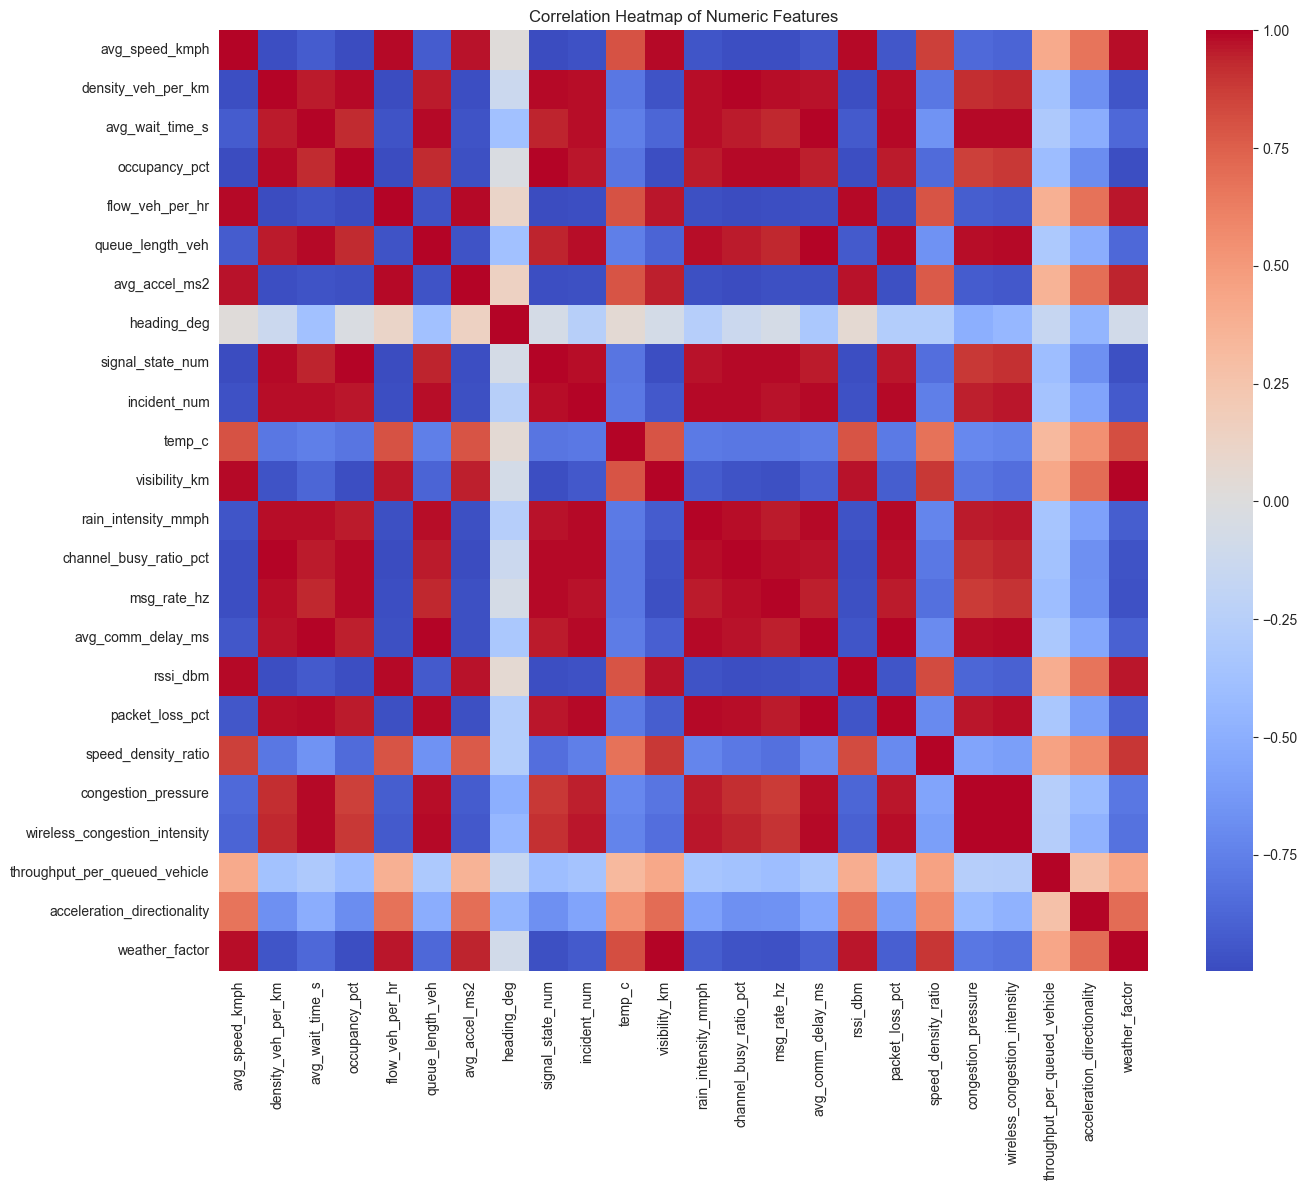

In [24]:
#Correlation Heatmap
plt.figure(figsize=(14, 12))
corr_matrix = df[numeric_features].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

Insight:Speed, density, occupancy, and queue length are highly correlated with each other, which makes sense physically — they're all different ways of measuring the same underlying congestion state. This is useful signal for classification, but also means some features are redundant

C:\Users\manin\AppData\Local\Temp\ipykernel_27292\1616439613.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="avg_speed_kmph",
C:\Users\manin\AppData\Local\Temp\ipykernel_27292\1616439613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="label", y="density_veh_per_km",


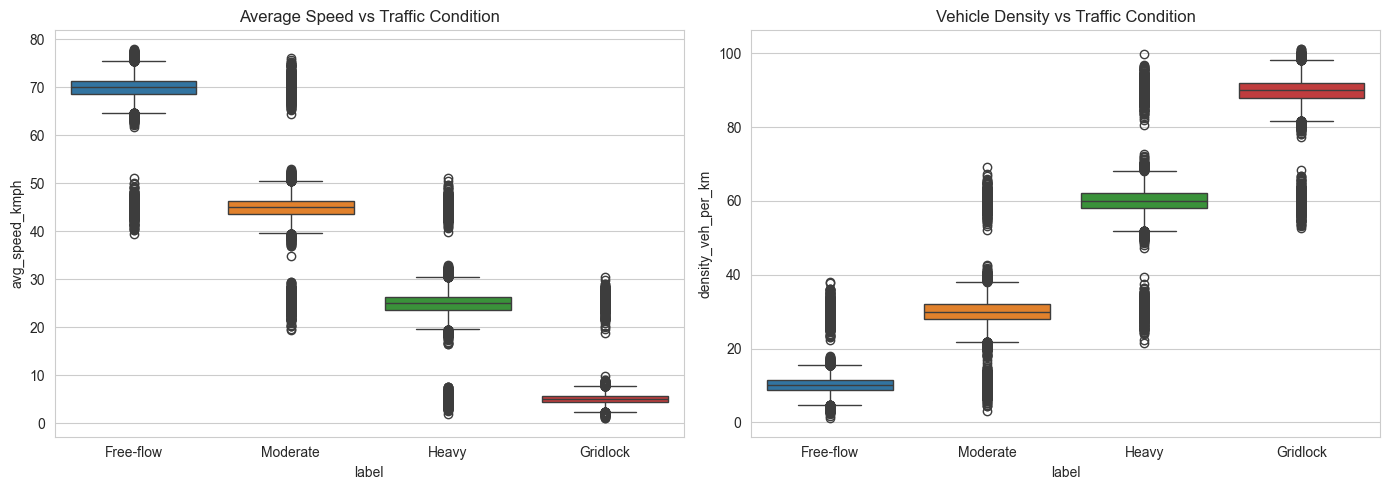

In [25]:
#Box Plots 
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x="label", y="avg_speed_kmph", 
            order=["Free-flow","Moderate","Heavy","Gridlock"], ax=axes[0], palette="tab10")
axes[0].set_title("Average Speed vs Traffic Condition")

sns.boxplot(data=df, x="label", y="density_veh_per_km", 
            order=["Free-flow","Moderate","Heavy","Gridlock"], ax=axes[1], palette="tab10")
axes[1].set_title("Vehicle Density vs Traffic Condition")

plt.tight_layout()
plt.show()

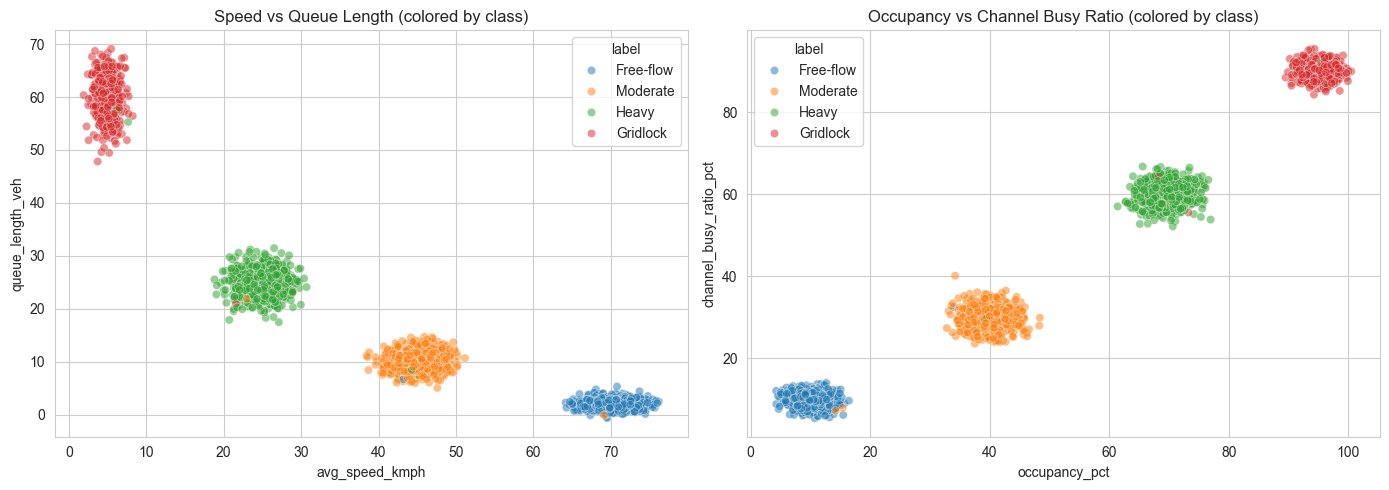

In [26]:
#Scatter Plots (Feature vs Target Relationship)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.scatterplot(data=df.sample(3000, random_state=42), x="avg_speed_kmph", y="queue_length_veh", 
                 hue="label", hue_order=["Free-flow","Moderate","Heavy","Gridlock"], ax=axes[0], alpha=0.5)
axes[0].set_title("Speed vs Queue Length (colored by class)")

sns.scatterplot(data=df.sample(3000, random_state=42), x="occupancy_pct", y="channel_busy_ratio_pct", 
                 hue="label", hue_order=["Free-flow","Moderate","Heavy","Gridlock"], ax=axes[1], alpha=0.5)
axes[1].set_title("Occupancy vs Channel Busy Ratio (colored by class)")

plt.tight_layout()
plt.show()

Insights:Box plots and sampled scatter plots illustrate how physical features like speed and density distinctively separate the four traffic classes. These legitimate real-time sensor measurements, supplemented by secondary communication-layer data, provide valid inputs for the classification model rather than future outcomes. You can read the full analysis in the project documentation.

In [27]:
#Check Invalid / Suspicious Values
# Physically impossible values to check
checks = {
    "avg_wait_time_s < 0": (df["avg_wait_time_s"] < 0).sum(),
    "queue_length_veh < 0": (df["queue_length_veh"] < 0).sum(),
    "occupancy_pct > 100": (df["occupancy_pct"] > 100).sum(),
    "occupancy_pct < 0": (df["occupancy_pct"] < 0).sum(),
    "rain_intensity_mmph < 0": (df["rain_intensity_mmph"] < 0).sum(),
    "packet_loss_pct > 100": (df["packet_loss_pct"] > 100).sum(),
    "avg_speed_kmph < 0": (df["avg_speed_kmph"] < 0).sum(),
}

for check, count in checks.items():
    print(f"{check}: {count}")

avg_wait_time_s < 0: 350
queue_length_veh < 0: 379
occupancy_pct > 100: 208
occupancy_pct < 0: 0
rain_intensity_mmph < 0: 26698
packet_loss_pct > 100: 0
avg_speed_kmph < 0: 0


In [28]:
#Apply the Fixes
print("Before cleaning:")
print("  Negative wait times:", (df["avg_wait_time_s"] < 0).sum())
print("  Negative queue lengths:", (df["queue_length_veh"] < 0).sum())
print("  Occupancy > 100:", (df["occupancy_pct"] > 100).sum())
print("  Negative rain intensity:", (df["rain_intensity_mmph"] < 0).sum())

# Clip physically impossible values to their valid minimum/maximum instead of deleting rows
df["avg_wait_time_s"] = df["avg_wait_time_s"].clip(lower=0)
df["queue_length_veh"] = df["queue_length_veh"].clip(lower=0)
df["occupancy_pct"] = df["occupancy_pct"].clip(upper=100)
df["rain_intensity_mmph"] = df["rain_intensity_mmph"].clip(lower=0)

print("\nAfter cleaning:")
print("  Negative wait times:", (df["avg_wait_time_s"] < 0).sum())
print("  Negative queue lengths:", (df["queue_length_veh"] < 0).sum())
print("  Occupancy > 100:", (df["occupancy_pct"] > 100).sum())
print("  Negative rain intensity:", (df["rain_intensity_mmph"] < 0).sum())

print("\nShape unchanged (no rows removed):", df.shape)

Before cleaning:
  Negative wait times: 350
  Negative queue lengths: 379
  Occupancy > 100: 208
  Negative rain intensity: 26698

After cleaning:
  Negative wait times: 0
  Negative queue lengths: 0
  Occupancy > 100: 0
  Negative rain intensity: 0

Shape unchanged (no rows removed): (195714, 27)


In [29]:
#Duplicate Check
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Duplicate rows: 0
Missing values: 0


In [30]:
#Feature Engineering (from timestamp)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Hour of day — traffic conditions vary strongly by time of day (rush hour effect)
df["hour_of_day"] = df["timestamp"].dt.hour

# Day of week — weekday vs weekend traffic patterns differ
df["day_of_week"] = df["timestamp"].dt.dayofweek  # 0=Monday, 6=Sunday

# Rush hour flag — a simple binary feature for morning/evening peak traffic
df["is_rush_hour"] = df["hour_of_day"].isin([7,8,9,17,18,19]).astype(int)

df[["timestamp","hour_of_day","day_of_week","is_rush_hour"]].head()

,timestamp,hour_of_day,day_of_week,is_rush_hour
0,2025-09-29 04:54:49,4,0,0
1,2025-09-30 06:15:38,6,1,0
2,2025-09-29 05:46:06,5,0,0
3,2025-09-28 21:15:29,21,6,0
4,2025-09-28 00:29:20,0,6,0


In [31]:
#One More Engineered Feature (communication-quality signal)
# Network reliability score: combines packet loss and comm delay into one signal
# Both indicate poor V2V communication quality, which tends to worsen under heavy congestion
df["network_reliability_score"] = df["packet_loss_pct"] + (df["avg_comm_delay_ms"] / 10)

df[["packet_loss_pct","avg_comm_delay_ms","network_reliability_score"]].head()

,packet_loss_pct,avg_comm_delay_ms,network_reliability_score
0,5.56,51.66,10.726
1,30.34,204.45,50.785
2,4.60,49.53,9.553
3,5.30,49.64,10.264
4,0.30,21.00,2.400


In [32]:
#Drop Non-Predictive Identifier Columns
print("Columns before dropping identifiers:", df.shape[1])

# timestamp: already broken into hour_of_day/day_of_week/is_rush_hour, so the raw value adds nothing more
# road_segment_id: a location label (500 unique values) — not a measurement, just an ID
print("Unique road_segment_id values:", df["road_segment_id"].nunique())

df = df.drop(columns=["timestamp", "road_segment_id"])

print("Columns after dropping identifiers:", df.shape[1])

Columns before dropping identifiers: 31
Unique road_segment_id values: 500
Columns after dropping identifiers: 29


In [33]:
#Prepare X and y
y = df["label"]
X = df.drop(columns=["label"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", y.unique())

X shape: (195714, 28)
y shape: (195714,)
Classes: <ArrowStringArray>
['Moderate', 'Gridlock', 'Free-flow', 'Heavy']
Length: 4, dtype: str


In [38]:
#Encode the Target Label
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original classes:", label_encoder.classes_)
print("Encoded as:", label_encoder.transform(label_encoder.classes_))

Original classes: ['Free-flow' 'Gridlock' 'Heavy' 'Moderate']
Encoded as: [0 1 2 3]


In [39]:
#Identify Numerical and Categorical Columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", len(numeric_cols))
print(numeric_cols)
print("\nCategorical features:", len(categorical_cols))
print(categorical_cols)

Numerical features: 26
['avg_speed_kmph', 'density_veh_per_km', 'avg_wait_time_s', 'occupancy_pct', 'flow_veh_per_hr', 'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 'signal_state_num', 'incident_num', 'temp_c', 'visibility_km', 'rain_intensity_mmph', 'channel_busy_ratio_pct', 'msg_rate_hz', 'avg_comm_delay_ms', 'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio', 'congestion_pressure', 'wireless_congestion_intensity', 'throughput_per_queued_vehicle', 'acceleration_directionality', 'weather_factor', 'is_rush_hour', 'network_reliability_score']

Categorical features: 0
[]


All 28 columns are numeric — categorical_cols will be an empty list, since road_segment_id (the only categorical column) was already dropped

In [40]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("\nClass balance in y_train:\n", pd.Series(y_train).value_counts(normalize=True))
print("\nClass balance in y_test:\n", pd.Series(y_test).value_counts(normalize=True))

X_train: (156571, 28)
X_test: (39143, 28)

Class balance in y_train:
 0    0.295393
3    0.276003
2    0.242395
1    0.186209
Name: proportion, dtype: float64

Class balance in y_test:
 0    0.295378
3    0.276014
2    0.242393
1    0.186215
Name: proportion, dtype: float64


In [41]:
#ColumnTransformer (Scaling + Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [42]:
#Fit on Train Only, Transform Both (No Leakage)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (156571, 26)
X_test_processed shape: (39143, 26)


In [43]:
#Show Cleaned Dataset & Save
print("=== CLEANED DATASET SUMMARY ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Engineered features added: hour_of_day, day_of_week, is_rush_hour, network_reliability_score")

df.head(10)

=== CLEANED DATASET SUMMARY ===
Shape: (195714, 29)
Missing values: 0
Duplicate rows: 0
Engineered features added: hour_of_day, day_of_week, is_rush_hour, network_reliability_score


,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,signal_state_num,incident_num,...,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label,hour_of_day,day_of_week,is_rush_hour,network_reliability_score
0,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,2.065,0.510,...,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate,4,0,0,10.726
1,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,3.971,2.088,...,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock,6,1,0,50.785
2,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,2.033,0.437,...,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate,5,0,0,9.553
3,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,1.943,0.467,...,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate,21,6,0,10.264
4,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,0.937,-0.101,...,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow,0,6,0,2.400
5,26.35,56.95,48.62,68.42,816.24,23.03,-0.235,274.17,2.909,0.978,...,27.6906,9.1637,35.4376,-64.4707,62.4084,Heavy,12,0,0,24.599
6,71.29,8.81,4.03,11.30,2018.04,3.29,0.783,85.47,1.021,0.045,...,0.3548,0.0397,613.1458,66.9173,283.3276,Free-flow,2,6,0,2.661
7,69.40,9.94,7.63,10.34,1974.18,2.70,0.893,83.50,0.960,-0.055,...,0.7589,0.0409,732.2152,74.5782,253.7678,Free-flow,10,6,0,2.593
8,70.53,11.48,5.27,11.25,1904.79,1.81,0.754,88.93,1.031,0.061,...,0.6051,0.0472,1053.4568,67.0112,288.5045,Free-flow,6,6,0,2.598
9,68.12,8.78,8.33,5.89,1971.50,2.16,0.750,88.23,1.005,-0.001,...,0.7309,0.0360,912.6261,66.1681,299.8441,Free-flow,11,6,0,2.210


In [44]:
df.to_csv("../data/vanet_traffic_data_cleaned.csv", index=False)
print("Saved cleaned dataset to ../data/vanet_traffic_data_cleaned.csv")

Saved cleaned dataset to ../data/vanet_traffic_data_cleaned.csv
